<a href="https://colab.research.google.com/github/hmmnyamminji/DL/blob/main/day13_practice2_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# GAN(이미지생성) - 생성자(위조지폐범) vs 판별자(경찰)의 경쟁 학습
# 순수 노이즈에서 손글씨 숫자가 '생겨나는' 과정

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 20
NOISE_DIM = 64  # 생성자의 입력: 의미 없는 난수 64개

In [3]:
# 셀 1. 데이터 - MNIST 손글씨

def load_mnist(root="./data"):
  tf = transforms.ToTensor() # 이미지(0-255) → 텐서(0.0-1.0)로 변환
  return datasets.MNIST(root=root, train=True, download=True, transform=tf)

train_data = load_mnist()
loader = DataLoader(train_data, batch_size=256, shuffle=True) # 256장씩 묶고 매 에폭 섞기

In [11]:
# 셀 2. 생성자 G 와 판별자 D

G = nn.Sequential(      # 위조지폐범, 생성자(Generator): 난수 64개 → 가짜 이미지 784
    nn.Linear(NOISE_DIM, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(), # 렐루 (ReLU - Rectified Linear Unit): 출력 0 또는 양의 무한대, 음수 => 0
    nn.Linear(512, 784), nn.Tanh(), # 하이퍼블릭 탄젠트 (Hyperbolic Tangent, Tanh) : 출력 -1과 1 사이
).to(device)

D = nn.Sequential( #이진분류기     # 경찰, 판별자(Discriminator): 이미지 784 → 진짜일 확률 1개
    nn.Flatten(),       # (1,28,28) → 784
    nn.Linear(784, 256), nn.LeakyReLU(0.2),  # LeakyReLU: 음수도 0.2배 통과(GAN 관례), 음수x0.2
    nn.Linear(256, 1), nn.Sigmoid(), # 진짜일 확률
).to(device)

loss_fn = nn.BCELoss()
opt_G = torch.optim.Adam(G.parameters(), lr=0.0002)
opt_D = torch.optim.Adam(D.parameters(), lr=0.0002)

In [12]:
# 셀 3. 경쟁 학습 - 한 배치마다 두 번의 학습
fixed_noise = torch.randn(16, NOISE_DIM).to(device) # 고정 난수 16개 (성장 관찰용), 16x64
snapshots = {} # {에폭: [생성이미지16개]} 저장용 딕셔너리

for epoch in range(EPOCHS):
  for real, _ in loader: # 진짜 이미지 배치
    real = real.reshape(-1, 784).to(device) # (8,1,28,28) → (8, 784)
    B = real.size(0) # 이번 에폭의 배치 크기
    ones, zeros = torch.ones(B, 1).to(device), torch.zeros(B, 1).to(device) # 정답표: 진짜는 (B,1), 가짜는 (B,0) 모양

    # 경찰 판별자(D) 훈련: 진짜는 1, 가짜는 0 이라고 맞히도록
    fake = G(torch.randn(B, NOISE_DIM).to(device)) # G에 무작위 난수를 입력해서 배치 크기 만큼의 가짜 이미지를 생성
    d_loss = loss_fn(D(real), ones) + loss_fn(D(fake.detach()), zeros) # D 손실 = 진짜를 1로 + 가짜를 0으로 (두 손실의 합), .detach()
    opt_D.zero_grad() # D 갱신
    d_loss.backward()
    opt_D.step()

    # 위조범 생성(G) 훈련: 경찰이 '진짜(1)'라고 속도록
    fake = G(torch.randn(B, NOISE_DIM).to(device)) # 새 가짜 생성 이미지 (이번엔 detach 안 함), 생성자를 학습시킬 것이므로
    g_loss = loss_fn(D(fake), ones) # 가짜인데 정답을 1로 속이는게 목표
    opt_G.zero_grad() # G 갱신
    g_loss.backward()
    opt_G.step()

  print(f"epoch {epoch+1:2d}/{EPOCHS} | D loss {d_loss.item():.3f} | G loss {g_loss.item():.3f}")

  # 특정 에폭 (첫 · 중간 · 마지막)에만 스냅샷 저장
  if epoch + 1 in {1, EPOCHS // 2, EPOCHS}:
    with torch.no_grad():
      snapshots[epoch + 1] = G(fixed_noise).reshape(-1, 1, 28, 28).cpu()

epoch  1/20 | D loss 1.188 | G loss 2.097
epoch  2/20 | D loss 0.668 | G loss 1.603
epoch  3/20 | D loss 1.558 | G loss 0.583
epoch  4/20 | D loss 1.221 | G loss 0.765
epoch  5/20 | D loss 1.429 | G loss 0.658
epoch  6/20 | D loss 1.392 | G loss 0.695
epoch  7/20 | D loss 1.282 | G loss 0.770
epoch  8/20 | D loss 1.075 | G loss 0.819
epoch  9/20 | D loss 0.803 | G loss 1.097
epoch 10/20 | D loss 0.553 | G loss 2.391
epoch 11/20 | D loss 1.168 | G loss 1.075
epoch 12/20 | D loss 0.783 | G loss 1.246
epoch 13/20 | D loss 1.378 | G loss 0.893
epoch 14/20 | D loss 0.995 | G loss 1.232
epoch 15/20 | D loss 1.069 | G loss 1.063
epoch 16/20 | D loss 1.457 | G loss 0.776
epoch 17/20 | D loss 1.591 | G loss 1.456
epoch 18/20 | D loss 0.705 | G loss 1.406
epoch 19/20 | D loss 1.088 | G loss 1.180
epoch 20/20 | D loss 1.123 | G loss 1.096


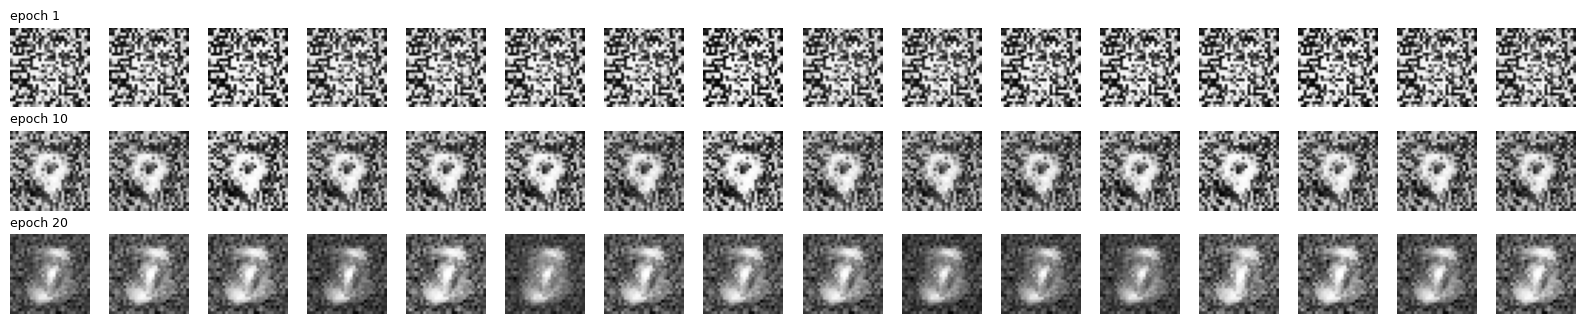

In [13]:
# 셀 4. 노이즈가 숫자가 되기까지 과정
fig, axes = plt.subplots(len(snapshots), 16, figsize=(16, len(snapshots) * 1.1), squeeze=False)
for row, (ep, imgs) in enumerate(sorted(snapshots.items())):
  for col in range(16):
    ax = axes[row, col]
    ax.imshow(imgs[col][0], cmap="gray")
    ax.axis("off")
    if col == 0:
      ax.set_title(f"epoch {ep}", loc="left", fontsize=9) # 행 맨 앞에 에폭 표시
plt.tight_layout()
plt.savefig("plot_ann_growth.png")
plt.show()